# What is IID, *exactly*?

> *"Treat the batch as IID."* — every loss in every training loop, ever.

This notebook makes the **independent and identically distributed** assumption tactile. We use `torch.distributions` to draw four kinds of $N$-sample datasets and see — visually and numerically — how each property can fail.

We end by showing **the log-likelihood factorisation** ($\log P(\mathcal{D} \mid \theta) = \sum_i \log P(Y_i \mid \theta)$) and how it **silently breaks** when independence is violated.

**Companion to** Lecture 0 · *A Probabilistic View of ML* · slide *"IID · the assumption that makes everything work"*.


In [1]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
np.random.seed(0)

# Plot styling to match the lecture theme
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "font.size": 10,
})
RUST, SLATE, SAGE, MUTED = "#B85A3E", "#4A6670", "#7B9E89", "#7B6E5A"


## The four cases

|                      | Identical                 | **Not** identical              |
|----------------------|---------------------------|--------------------------------|
| **Independent**      | textbook IID              | independent · drifting params  |
| **Not** independent  | same marginal · AR(1)     | the real-world worst case      |

We'll generate one $N = 200$ sample dataset for each.


---

## Case 1 · True IID

Every $Y_i$ comes from **the same** $\mathcal{N}(0, 1)$, and each sample is drawn **independently**. This is what "treat the batch as IID" assumes.


In [2]:
N = 200

# Independent + identical: a single distribution, N independent samples
base = dist.Normal(loc=0.0, scale=1.0)
iid_samples = base.sample((N,))
print(f"shape = {tuple(iid_samples.shape)}, mean = {iid_samples.mean():.3f}, std = {iid_samples.std():.3f}")


shape = (200,), mean = -0.023, std = 0.967


---

## Case 2 · Independent · **not** identical (drift)

Each $Y_i$ is independent, but the **distribution shifts** at every $i$. Mean drifts from $-3$ to $+3$ linearly across the dataset.

Real-world examples · sensor drift over months, dataset shift between user cohorts, non-stationary stock returns.


In [3]:
# Each sample comes from a DIFFERENT Normal — independent, not identical.
mus = torch.linspace(-3.0, 3.0, N)                      # drifting mean
nonid_samples = dist.Normal(mus, scale=1.0).sample()    # one draw each
print(f"shape = {tuple(nonid_samples.shape)}, mean = {nonid_samples.mean():.3f}, std = {nonid_samples.std():.3f}")


shape = (200,), mean = -0.042, std = 2.046


---

## Case 3 · Identical · **not** independent (autocorrelated)

Every sample has the **same marginal** $\mathcal{N}(0, 1)$, but each step is correlated with the previous one — an AR(1) process ·

$$Y_t = \phi\, Y_{t-1} + \epsilon_t,\quad \epsilon_t \sim \mathcal{N}(0, 1 - \phi^2)$$

The variance scaling $1 - \phi^2$ keeps every $Y_t$'s marginal as $\mathcal{N}(0, 1)$ — the *identical* part holds. But $Y_{t-1}$ tells you a lot about $Y_t$.

Real-world examples · text tokens, audio frames, video, anything with a time index.


In [4]:
phi = 0.9                          # correlation between consecutive samples
eps = dist.Normal(0.0, (1 - phi**2) ** 0.5).sample((N,))
ar1 = torch.zeros(N)
ar1[0] = dist.Normal(0.0, 1.0).sample()
for t in range(1, N):
    ar1[t] = phi * ar1[t - 1] + eps[t]
print(f"shape = {tuple(ar1.shape)}, mean = {ar1.mean():.3f}, std = {ar1.std():.3f}")


shape = (200,), mean = 0.145, std = 1.050


---

## Case 4 · Neither independent nor identical

Drift **plus** autocorrelation. The real-world worst case. (Think · video of a person walking through a changing landscape — frames are correlated AND the scene drifts.)


In [5]:
phi = 0.85
mus_drift = torch.linspace(-3.0, 3.0, N)
eps2 = dist.Normal(0.0, (1 - phi**2) ** 0.5).sample((N,))
worst = torch.zeros(N)
worst[0] = dist.Normal(mus_drift[0], 1.0).sample()
for t in range(1, N):
    worst[t] = phi * worst[t - 1] + mus_drift[t] * (1 - phi) + eps2[t]
print(f"shape = {tuple(worst.shape)}, mean = {worst.mean():.3f}, std = {worst.std():.3f}")


shape = (200,), mean = -0.195, std = 1.703


---

## Visualise · scatter, histogram, autocorrelation

For each case we plot ·

- **Sequence view** · $Y_i$ vs $i$ — drift jumps out here.
- **Histogram** · the *marginal* — identical cases overlay.
- **Autocorrelation** at lag 1 · how much does $Y_t$ predict $Y_{t+1}$?

A truly IID dataset is the **only** one where the sequence looks structureless AND the lag-1 autocorrelation is ~0.


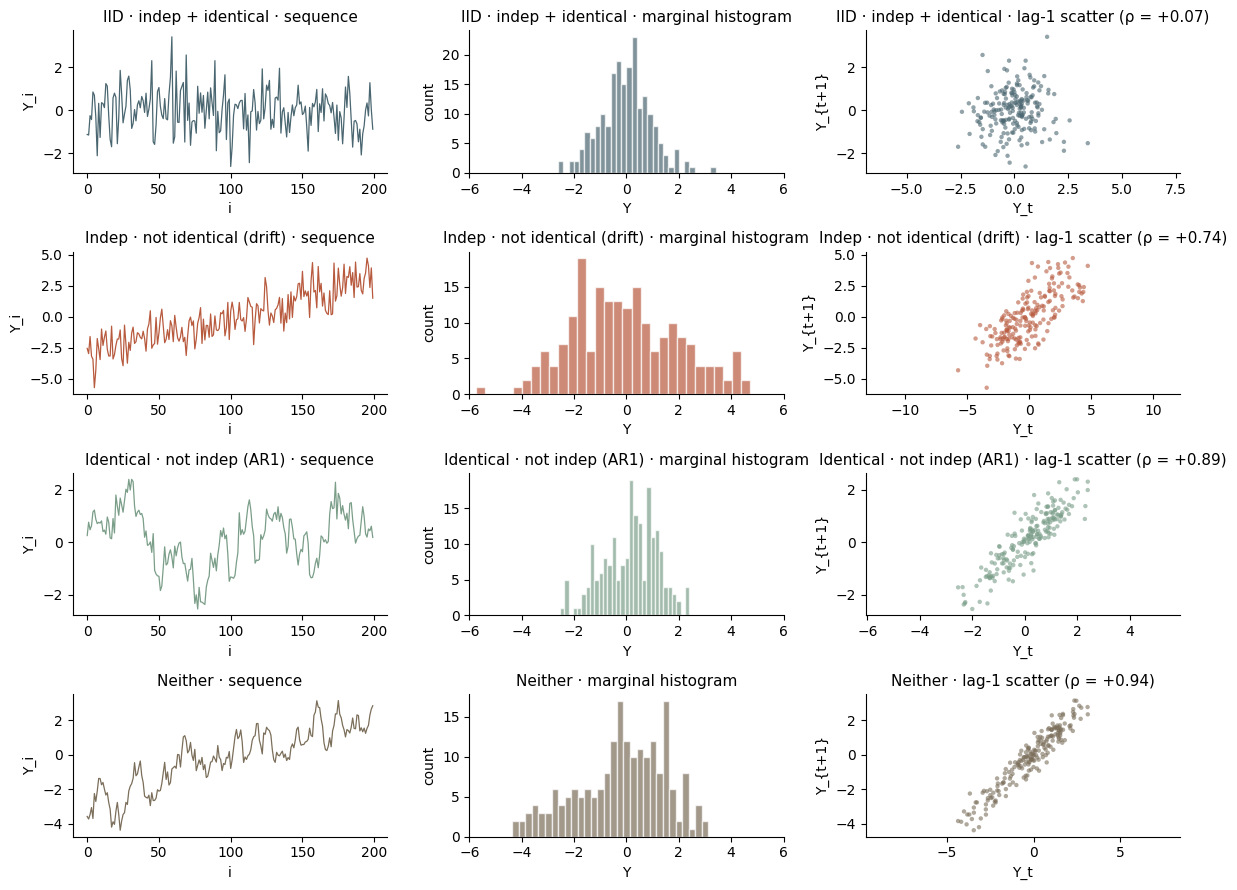

In [6]:
def autocorr_lag1(x):
    x = x - x.mean()
    return (x[:-1] * x[1:]).sum() / (x * x).sum()

cases = [
    ("IID · indep + identical", iid_samples, SLATE),
    ("Indep · not identical (drift)", nonid_samples, RUST),
    ("Identical · not indep (AR1)", ar1, SAGE),
    ("Neither", worst, MUTED),
]

fig, axes = plt.subplots(4, 3, figsize=(12, 9))
for row, (name, y, color) in enumerate(cases):
    y = y.numpy()
    ax_seq, ax_hist, ax_scatter = axes[row]

    # Sequence view
    ax_seq.plot(range(N), y, color=color, lw=0.9)
    ax_seq.set_title(f"{name} · sequence")
    ax_seq.set_xlabel("i"); ax_seq.set_ylabel("Y_i")

    # Histogram (the marginal distribution)
    ax_hist.hist(y, bins=30, color=color, alpha=0.7, edgecolor="white")
    ax_hist.set_title(f"{name} · marginal histogram")
    ax_hist.set_xlabel("Y"); ax_hist.set_ylabel("count")
    ax_hist.set_xlim(-6, 6)

    # Lag-1 scatter: Y_t+1 vs Y_t
    ax_scatter.scatter(y[:-1], y[1:], s=10, color=color, alpha=0.6, edgecolor="none")
    rho = float(autocorr_lag1(torch.tensor(y)))
    ax_scatter.set_title(f"{name} · lag-1 scatter (ρ = {rho:+.2f})")
    ax_scatter.set_xlabel("Y_t"); ax_scatter.set_ylabel("Y_{t+1}")
    ax_scatter.set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()


**What you should see**

- **Row 1 · IID** · sequence has no trend; histogram is a bell; lag-1 scatter is a blob with ρ near 0.
- **Row 2 · Drift** · sequence visibly slopes; histogram is flatter (mixed Normals); lag-1 ρ small but the scatter is *correlated by index*.
- **Row 3 · AR(1)** · sequence wanders smoothly; histogram still bell-shaped; lag-1 scatter shows a strong diagonal — ρ ≈ 0.9.
- **Row 4 · Neither** · drift + autocorrelation. Hardest case for any "summed loss" assumption.

Move on for the punchline · what does this break in training?


---

## The product factorisation · *and how non-IID breaks it*

Under IID we factor the dataset log-likelihood ·

$$\log P(\mathcal{D} \mid \theta) \;=\; \log \prod_{i=1}^N P(Y_i \mid \theta) \;=\; \sum_{i=1}^N \log P(Y_i \mid \theta)$$

The right-hand side is what every training loop computes · *sum the per-example loss*. **This is only equal to the true log-likelihood when the samples are IID.**

Let's compute both for our four cases, assuming the model is the "all-data $\mathcal{N}(0, 1)$" — the wrong distribution for cases 2, 3, 4 — and see how the *sum-of-per-example* score lies to us about how good the model is.


In [7]:
model = dist.Normal(loc=0.0, scale=1.0)  # the model we *would* fit under IID

# What the training loop computes: sum of per-example log p(y | theta)
def sum_logp(y):
    return model.log_prob(y).sum().item()

for name, y, _ in cases:
    s = sum_logp(y)
    print(f"{name:34s}  sum log p(y|theta) = {s:8.2f}   (per-example {s / N:+.3f})")


IID · indep + identical             sum log p(y|theta) =  -276.96   (per-example -1.385)
Indep · not identical (drift)       sum log p(y|theta) =  -600.60   (per-example -3.003)
Identical · not indep (AR1)         sum log p(y|theta) =  -295.50   (per-example -1.478)
Neither                             sum log p(y|theta) =  -476.32   (per-example -2.382)


**Reading the numbers**

- For the true IID case, the sum-of-log-probs reflects the actual data fit · we are scoring an $\mathcal{N}(0, 1)$ sample under $\mathcal{N}(0, 1)$, which is the *right* model.
- For the drift case, the per-example score collapses · the model puts low density on the tails the drift visits.
- For the AR(1) case, the per-example score *looks fine* (the marginal is correct!) — but the **likelihood of the whole sequence** is much smaller than the product, because the true generative process has $\phi = 0.9$ couplings we ignored. The "summed loss" silently lies.

This is exactly why ·

- Time-series models use autoregressive factorisation · $\prod_t P(Y_t \mid Y_{<t}, \theta)$.
- LLMs maximise $\sum_t \log P(Y_t \mid Y_{<t})$ rather than $\sum_t \log P(Y_t)$.
- "Treat the batch as IID" works only after **shuffling** breaks any temporal coupling.

---

## A clean ablation · the shuffled AR(1)

If you **shuffle** the AR(1) samples, the marginal is unchanged (still $\mathcal{N}(0, 1)$) but the temporal correlation is destroyed. The sum-of-log-probs score is the same — because $\log p$ doesn't know about order. But the *true joint likelihood* of the AR(1) sequence is much smaller than the product. Shuffling matches what the IID assumption *thinks* the data looks like.


In [8]:
ar1_shuffled = ar1[torch.randperm(N)]

print("AR(1) original lag-1 ρ:", float(autocorr_lag1(ar1)))
print("AR(1) shuffled lag-1 ρ:", float(autocorr_lag1(ar1_shuffled)))

print("\nSum log p under model N(0,1):")
print(f"  AR(1) original  : {sum_logp(ar1):.2f}")
print(f"  AR(1) shuffled  : {sum_logp(ar1_shuffled):.2f}")


AR(1) original lag-1 ρ: 0.8925305008888245
AR(1) shuffled lag-1 ρ: -0.02539406530559063

Sum log p under model N(0,1):
  AR(1) original  : -295.50
  AR(1) shuffled  : -295.50


The two sums are **identical** — the per-example score can't see the difference. Yet the underlying processes are wildly different (one has $\phi = 0.9$, the other has $\phi = 0$).

This is the hidden assumption baked into every gradient step you take. **Shuffle your data.** Or, if you can't (sequences), use an autoregressive model.

---

## Try this

1. **Change $\phi$** to 0.5 — does AR(1) start looking IID-ish in the lag-1 scatter?
2. **Make drift sub-linear** (e.g. `mus = torch.sin(torch.linspace(0, 4 * torch.pi, N))`) — what does the marginal histogram look like?
3. **Compute the *true* AR(1) log-likelihood** using $P(Y_t \mid Y_{t-1}) = \mathcal{N}(\phi Y_{t-1}, 1 - \phi^2)$ and verify that the *autoregressive* score does see the difference between AR(1) and its shuffle.

---

## Takeaways

- **IID = identical (same distribution) AND independent (no coupling)**. Both must hold for the product factorisation.
- The **marginal histogram** detects identical-ness; the **lag-1 scatter / autocorrelation** detects independence.
- The training-loop loss `sum(log p(y))` is **blind to independence violations**. Shuffling rescues it; sequence models replace it with $\prod_t p(y_t \mid y_{<t})$.

Back to the slides · *IID is the formal license to add up per-example losses.*
